# Hikrobot GigE (PoE) — bench test

Interactive check of the `HikRobot` driver against the camera at **10.0.1.50**.

**Prerequisites (Windows):**
- Hikrobot **MVS** installed — the driver finds the bindings/DLL automatically, even in a process launched before the install
- The camera reachable from this PC: **NIC on the same subnet** (e.g. host `10.0.1.x/24`), MVS client closed (GigE control is **exclusive** — the MVS viewer holding the camera blocks us)
- `numpy`, `opencv-python`, `matplotlib` in this Python environment

⚠️ **Cross-subnet does not work for open** (verified on this bench): with the PC on `10.0.3.x` Wi-Fi and the camera on `10.0.1.x`, ping and the accessibility query pass through the router, but `connect` fails with `MV_E_UDP_RECV_DATA` — the open handshake needs the *camera* to initiate flows back to the PC, and stateful routers drop those. Fix: plug this PC into the camera's PoE switch (NIC gets a `10.0.1.x` address), or run the same test from the Pi, which already shares the camera's subnet.

In [1]:
# Run from the example/ folder — put the repo root on the path
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from camera import HikRobot

CAMERA_IP = "10.0.1.50"

## 1. Discover cameras on the network
Empty list = SDK missing **or** no camera answering discovery (check PoE link / subnet / firewall — GigE discovery is UDP broadcast).

In [2]:
HikRobot.all_device()

[{'serial_number': 'DB1119554',
  'name': 'MV-CU060-10GC',
  'user_name': '',
  'ip': '10.0.1.50',
  'camera_type': 'hikrobot'},
 {'serial_number': 'DB1119554',
  'name': 'MV-CU060-10GC',
  'user_name': '',
  'ip': '10.0.1.50',
  'camera_type': 'hikrobot'}]

## 2. Connect
`raise_on_fail=True` so a failure shows the actionable message instead of a silent `False`.

In [3]:
cam = HikRobot()

# Wired gigabit (normal case): no arguments — full sensor at max fps.
# The driver actively RESETS binning / fps-cap / packet-delay registers
# that a previous session may have left persisted on the camera.
cam.connect(ip=CAMERA_IP, raise_on_fail=True)

# Lossy Wi-Fi bench instead? use:
# cam.connect(ip=CAMERA_IP, stream={"fps": 5}, packet_delay=2000,
#             binning=2, raise_on_fail=True)

print("serial:       ", cam.serial_number)
print("ip:           ", cam.ip)
print("stream_actual:", cam.stream_actual)
print("state:        ", cam.state)

serial:        DB1119554
ip:            10.0.1.50
stream_actual: {'width': 3072, 'height': 2048, 'fps': 18.44}
state:         ok


## 3. Grab a frame and show it

Same 9-tuple shape as the D405 so existing code can unpack it unchanged. **This camera has no depth** — slots 1-5 (depth frame, ir frame, depth/ir images) are all `None`. The 7th slot is called `depth_int` only for D405 signature compatibility: it holds the **camera intrinsics** (K-matrix numbers), not depth data.

Over Wi-Fi, grabs intermittently raise `_TransientGrabError` (packet loss killed the frame mid-assembly) — the session stays alive, so the loop below just retries until a frame lands. Wired links won't need this.

attempt 0: frame (2048, 3072, 3) dtype=uint8


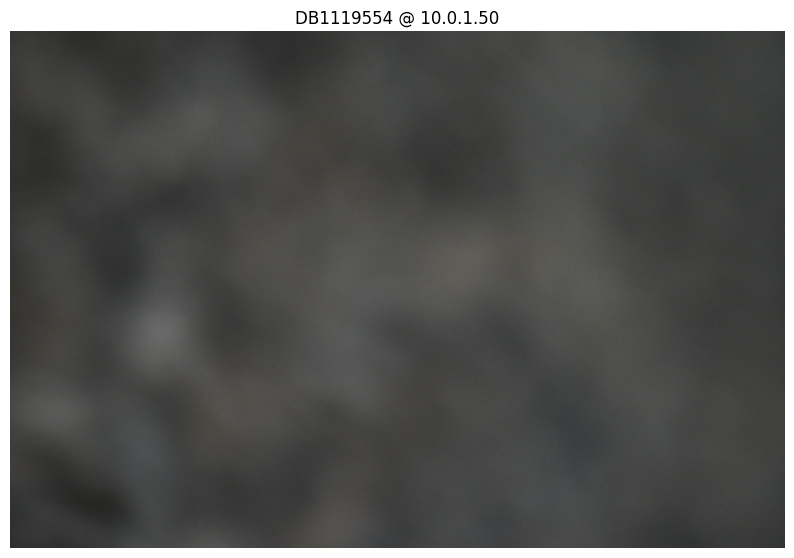

In [4]:
import cv2
import matplotlib.pyplot as plt

# retry until a complete frame survives the link (Wi-Fi drops frames
# mid-assembly; each failed try already waited up to 15s internally)
color_img = None
for attempt in range(10):
    try:
        _, _, _, _, _, color_img, depth_int, _, ts = cam.get_all()
        print(f"attempt {attempt}: frame {color_img.shape} dtype={color_img.dtype}")
        break
    except Exception as ex:
        print(f"attempt {attempt}: {type(ex).__name__} — retrying")
assert color_img is not None, "no complete frame in 10 tries — use the wired link"

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title(f"{cam.serial_number} @ {cam.ip}")
plt.axis("off")
plt.show()

## 4. Intrinsics
Without authored `K`/`D` this is the **nominal placeholder** (focal = image width, centered pp) — fine for drawing, not for metric work.

In [5]:
print("source:", cam.intr_source)
print("K:", cam.get_K())
print("D:", cam.get_D())

source: nominal
K: [[3072.0, 0.0, 1536.0], [0.0, 3072.0, 1024.0], [0.0, 0.0, 1.0]]
D: [0.0, 0.0, 0.0, 0.0, 0.0]


## 5. Exposure & white balance
Real knobs on this sensor. Exposure is in **µs** (same unit as the D405).

auto exposure now: 53808.0 us
pinned: 10000.0 us
back to auto: 1415.0 us


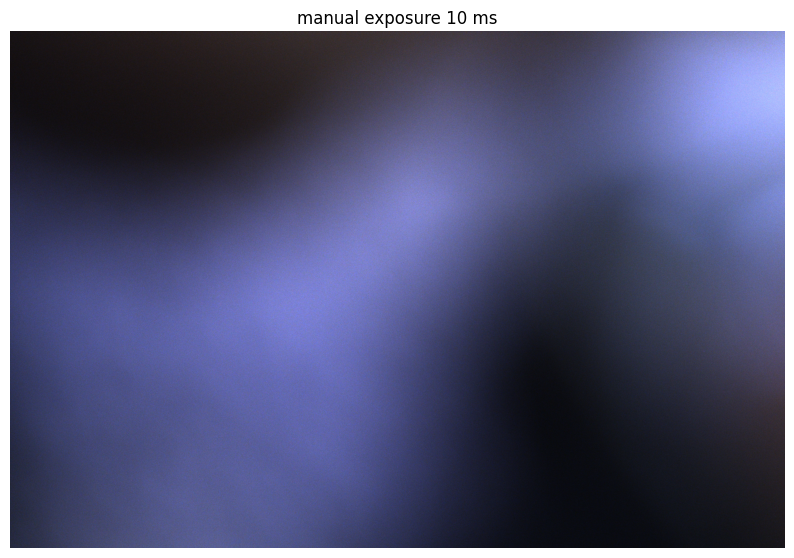

In [6]:
print("auto exposure now:", cam.get_exposure(), "us")

# pin a manual exposure, grab, compare — then back to auto
print("pinned:", cam.set_exposure(10000), "us")   # 10 ms
_, _, _, _, _, img_manual, _, _, _ = cam.get_all()
print("back to auto:", cam.auto_exposure(True), "us")

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_manual, cv2.COLOR_BGR2RGB))
plt.title("manual exposure 10 ms")
plt.axis("off")
plt.show()

In [ ]:
# ── Recommended production recipe: converge AUTO, then PIN ──────────
# Deterministic frames beat adaptive ones for detection — auto that
# keeps adjusting mid-run shifts brightness/color on the same part.

# 1. let auto settle on the real scene + lighting for a few frames
cam.auto_exposure(True)
cam.white_balance({"auto": True})
for _ in range(10):
    cam.get_all()

# 2. pin what auto converged to
exp = cam.get_exposure()
print("pinned exposure:", cam.set_exposure(exp), "us")
print("held WB:        ", cam.white_balance({"hold": True}))

# Manual overrides, any time:
#   cam.set_exposure(5000)               # exact µs (short = less motion blur)
#   cam.auto_exposure(True)              # back to auto exposure
#   cam.white_balance({"auto": True})    # back to auto WB
#   cam.white_balance({"once": True})    # one-shot converge, then hold

## 6. Live view — runs until you press ■ Stop

Continuous capture + display. Stop it with the notebook's **interrupt button** (■ next to the cell) — the loop catches the interrupt, prints stats, and the camera stays connected for the next cells.

Display uses JPEG frames via `IPython.display` (much faster than matplotlib). The camera delivers ~19 fps; the notebook display itself is the bottleneck, so `display_fps` < camera fps is normal.

'live:  18.2 fps  frame 3072x2048  #4871   (press ■ Stop to end)'

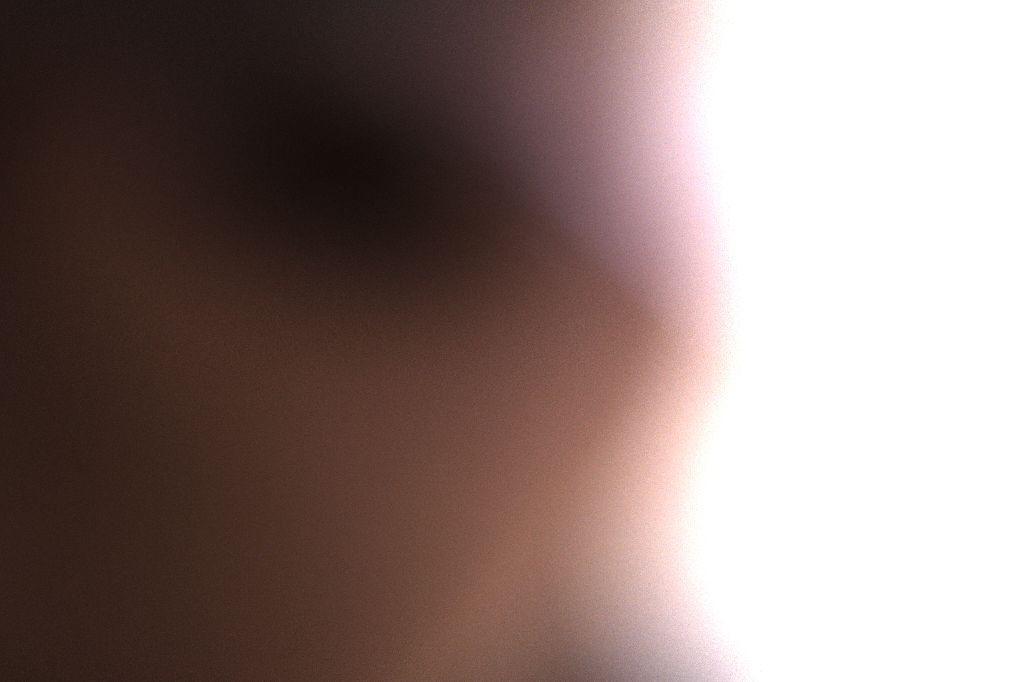

In [ ]:
import time
import cv2
from IPython.display import Image as IPyImage, display

MAX_SEC = None      # None = run until you press ■ Stop; or set seconds
SCALE   = 3         # display downscale (capture stays full-res)
JPEG_Q  = 80

def encode(img):
    small = cv2.resize(img, (img.shape[1] // SCALE, img.shape[0] // SCALE))
    return cv2.imencode(".jpg", small,
                        [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_Q])[1].tobytes()

# Create the two output areas ONCE, then update them in place —
# display handles never clear the cell output, so no blinking.
img = cam.get_all()[5]
status = display("live: starting…", display_id=True)
screen = display(IPyImage(data=encode(img)), display_id=True)

frames = 1
t0 = time.time()
try:
    while MAX_SEC is None or time.time() - t0 < MAX_SEC:
        img = cam.get_all()[5]
        frames += 1
        fps = frames / (time.time() - t0)
        status.update(f"live: {fps:5.1f} fps  frame {img.shape[1]}x{img.shape[0]}  "
                      f"#{frames}   (press ■ Stop to end)")
        screen.update(IPyImage(data=encode(img)))
except KeyboardInterrupt:
    pass
dt = time.time() - t0
status.update(f"stopped: {frames} frames in {dt:.1f}s -> {frames/dt:.1f} fps")

## 7. Throughput check
A few timed grabs — on wired gigabit expect the camera's max (~19 fps at full sensor). On Wi-Fi the success ratio is your link-quality meter.

In [1]:
import time

N = 20
good = 0
t0 = time.time()
for _ in range(N):
    try:
        cam.get_all()
        good += 1
    except Exception:
        pass
dt = time.time() - t0
print(f"{good}/{N} grabs ok in {dt:.1f}s"
      + (f"  ->  {good/dt:.1f} fps effective" if good else "  — link too lossy"))

0/20 grabs ok in 0.0s  — link too lossy


## 8. Close
Release the exclusive GigE control channel — the MVS viewer (or the Pi) can't open the camera while this notebook holds it.

In [ ]:
cam.close()